# Recommender Systems taxonomy

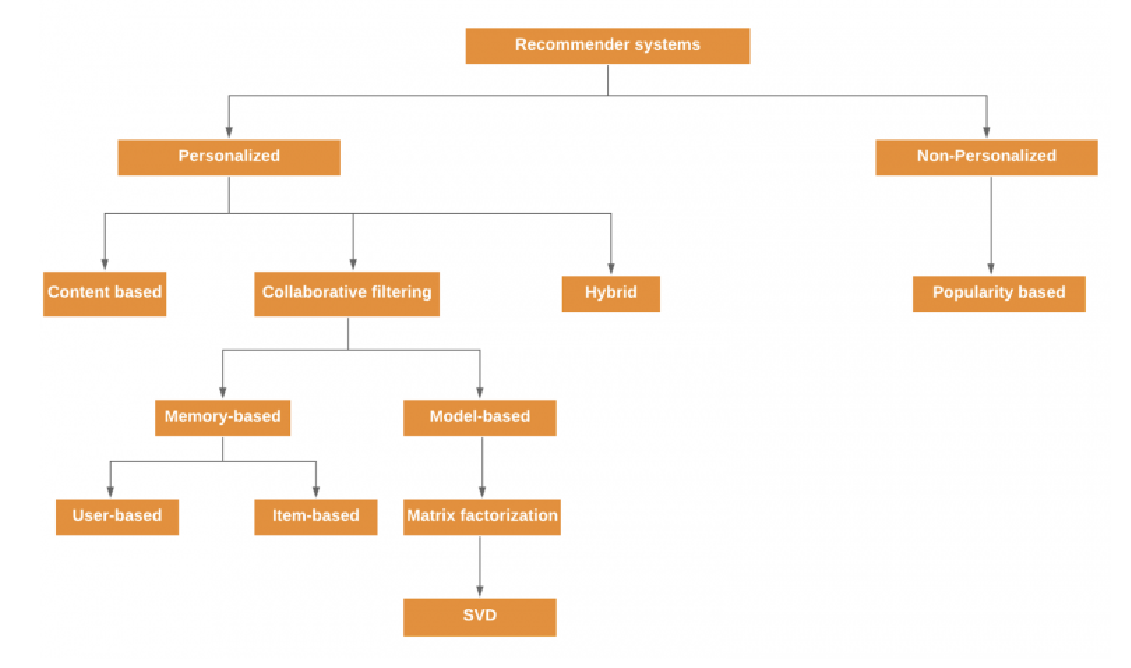

Non-personalized - don't consider person's interests, consider only global factors like popularity

Personalized - everything that is not personalized

## Problem statement

**Given:**
*   $U = \{u_j \mid j \in 1, \dots n_{\text{users}}\}$ — set of users
*   $I = \{i_j \mid j \in 1, \dots n_{\text{items}}\}$ — set of items
*   $R = \|r_{ui}\|$ — relation matrix of shape $n_{\text{users}} \times n_{\text{items}}$,
    $r_{ui} \in \begin{cases} \text{typically } \{0, 1\} & \text{— implicit feedback (add to cart, how long user listened song or watched clip, etc.)} \\ \text{typically } \{1, 2, 3, 4, 5\} & \text{— explicit feedback (buy, send feedback, etc.)} \end{cases}$

**Possible tasks:**

**Rating prediction**
*   Predict unknown $r_{ui}$ — regression or (multi-class) classification

**Top-k ranking** (most popular now)
*   Rank top-k recommendations for items — item2item
*   Rank top-k recommendations for users — item2user

### Evaluation metrics

Classic metrics from ranking tasks

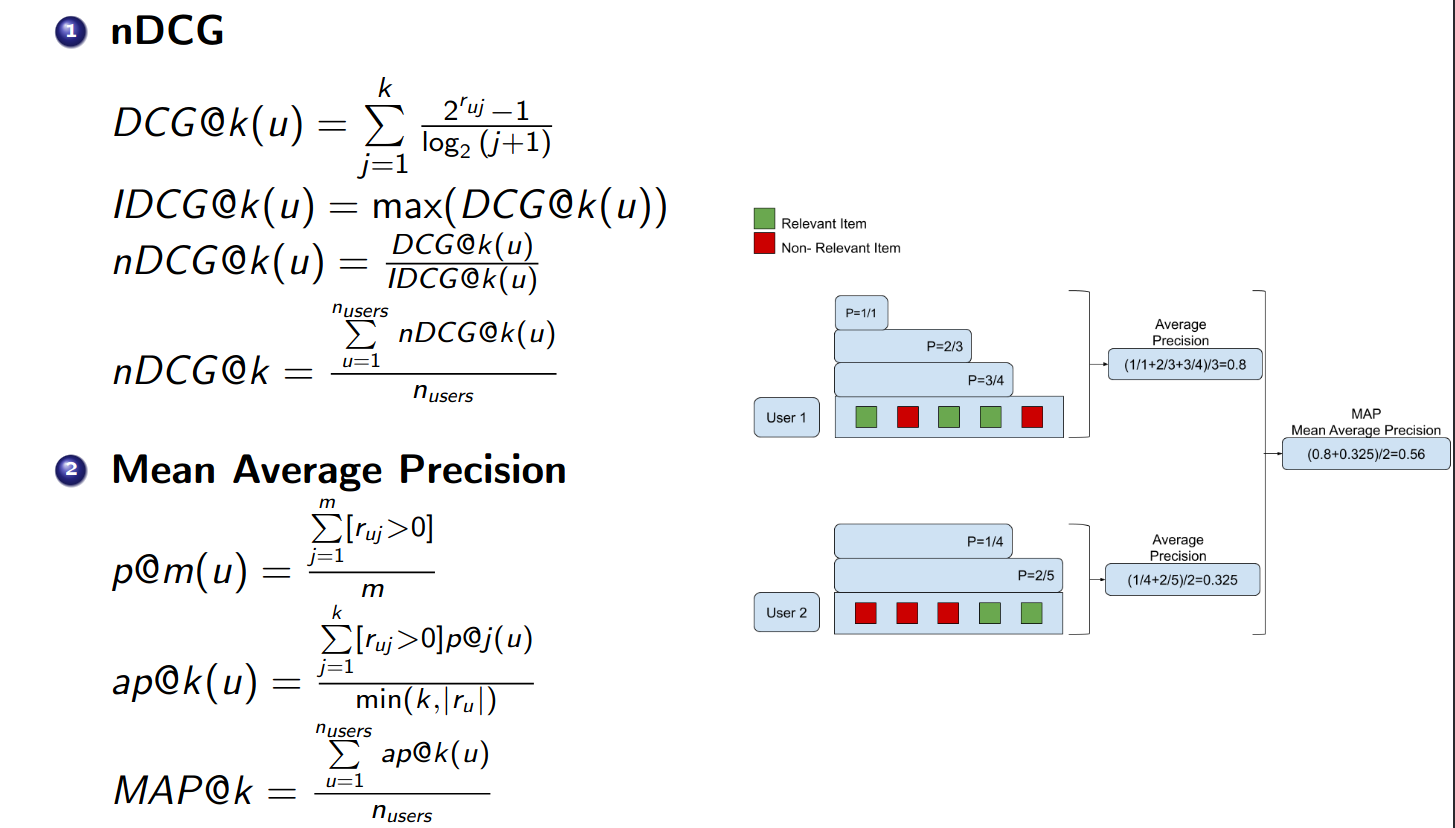

#### Hit Rate

This metric also measures some sort of recommendation precision: for user *u* it returns 1 if at least on of recommendations r<sub>uj</sub> for user *u* was relevant. Then average these values for all user and get the overall hit rate.

$$HitRate@K(u) = \max_{j \in [1..K]}\mathbb{1}_{r_{uj}}$$


$$ HitRate@K = \frac{\sum\limits_{u=1}^{N}HitRate@K(u)}{N} $$

$\mathbb{1}_{r_{uj}}$ -- indicator function stating that user $u$ interacted with item $j$


#### Coverage

This metric measures diversity of recommendations: calculate the number of all unique items that were recommended and divide it by number of all items.

$$Coverage@K=\frac{\left|\bigcup\limits_{u\in U} y_u\right|}{|I|}$$

### Collaborative filtering types

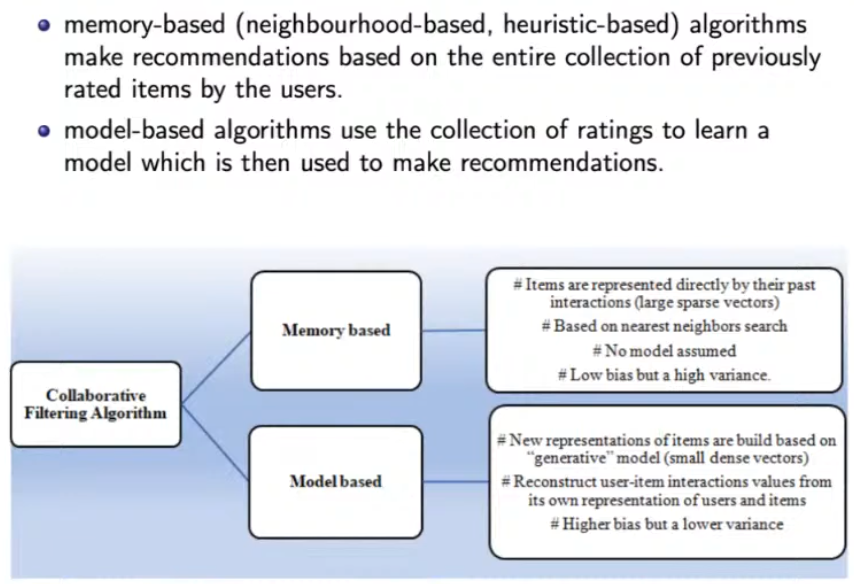

### Memory-based types

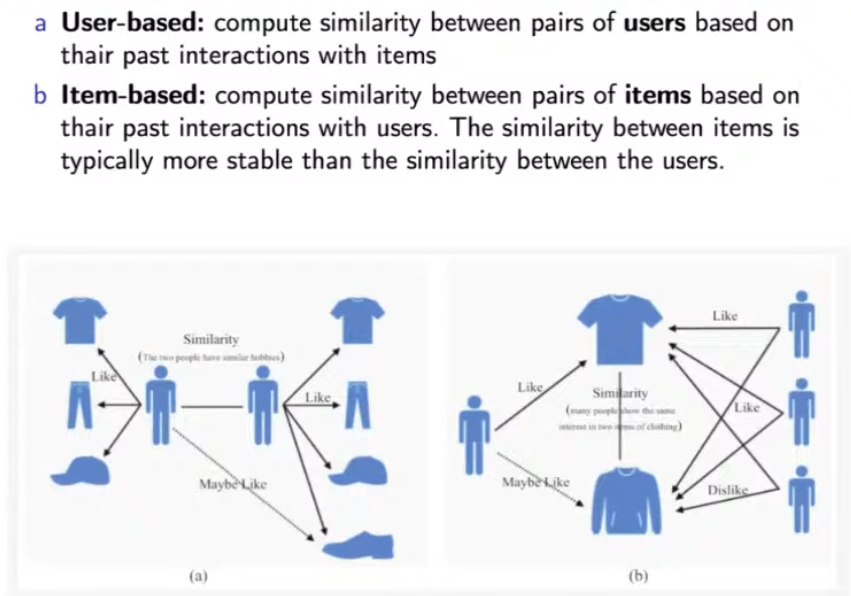

The prediction $r_{ui}$ is calculated by aggregating known ratings, categorized into two main approaches:
*   **User-based:** Aggregating ratings from similar users ($u' \in U_i$) who have rated the target item.
*   **Item-based:** Aggregating ratings from items similar to the target item that the user has already rated ($i' \in I_u$).

### Item-Based Aggregation Methods
1.  **Simple Average:**
    $$r_{ui} = \frac{1}{N} \sum_{i' \in I_u} r_{ui'}$$
    This calculates the arithmetic mean of all ratings the user has given to items similar to $i$.

2.  **Weighted Sum:**
    $$r_{ui} = k \sum_{i' \in I_u} \text{sim}(i, i') \times r_{ui'}$$
    This weights the user's past ratings by the similarity between the target item ($i$) and the previously rated items ($i'$).

3.  **Adjusted Weighted Sum (Mean-Centering):**
    $$r_{ui} = \bar{r}_{ui} + k \sum_{i' \in I_u} \text{sim}(i, i') \times (r_{ui'} - \bar{r}_{ui})$$
    This approach accounts for differences in rating scales by subtracting the mean rating of the item ($\bar{r}_i$) before weighting, and then adding it back to the final result.

**Normalization Factor ($k$):**
In the weighted formulas, $k$ is used to normalize the sum to ensure the prediction remains within a reasonable range:
$$k = \frac{1}{\sum_{i' \in I_u} |\text{sim}(i, i')|}$$

### How to calculate sim(i, j)?

#### Cosine Similarity
$$\text{Cosine}(i, j) = \frac{\sum_{u \in U_{ij}} r_{ui} \cdot r_{uj}}{\sqrt{\sum_{u \in U_{ij}} r_{ui}^2} \sqrt{\sum_{u \in U_{ij}} r_{uj}^2}}$$

This measures the cosine of the angle between two vectors of ratings. Each vector represents an item, and the dimensions are the users who have rated both items ($U_{ij}$). It considers the raw rating values. A value of 1 indicates the items are perfectly aligned in orientation, while 0 indicates they are orthogonal (no shared preference patterns).

#### Pearson Correlation ($PC$)
$$PC(i, j) = \frac{\sum_{u \in U_{ij}} (r_{ui} - \bar{r}_i)(r_{uj} - \bar{r}_j)}{\sqrt{\sum_{u \in U_{ij}} (r_{ui} - \bar{r}_i)^2 \sum_{u \in U_{ij}} (r_{uj} - \bar{r}_j)^2}}$$

Unlike the basic cosine, the Pearson Correlation is **mean-centered**. It subtracts the average rating of the item ($\bar{r}_i$ and $\bar{r}_j$) from each rating before calculating the correlation. This accounts for the fact that some items generally receive higher ratings than others (it removes the "bias" of an item's average rating). It measures how strongly the deviations of the two items from their respective means tend to move in the same direction.

#### Additional Weighting (e.g., IDF, BM25)
To prevent popular items from dominating similarity calculations, techniques borrowed from Natural Language Processing (NLP) are used to down-weight frequently rated items and highlight more specific, informative ratings.

*   **Inverse Document Frequency (IDF):** By incorporating an IDF weight ($\lambda_u$), the system gives more significance to ratings provided by users who are more "selective" (i.e., those who have rated fewer items).
    *   **Formula:** $\lambda_u = \log \frac{|I|}{|I_u|}$, where $|I|$ is the total number of items and $|I_u|$ is the number of items rated by user $u$.
*   **Weighted Cosine Similarity:** This modified version of the Cosine formula incorporates the weight $\lambda_u$ into the summation:
    $$\text{Cosine}(i,j) = \frac{\sum_{u \in U_{ij}} \lambda_u r_{ui} \cdot r_{uj}}{\sqrt{\sum_{u \in U_{ij}} \lambda_u r_{ui}^2} \sqrt{\sum_{u \in U_{ij}} \lambda_u r_{uj}^2}}$$

#### Shrink Coefficient (Shrinkage)
When there are very few shared ratings between two items ($|U_{ij}|$ is small), the calculated similarity can be statistically unreliable or biased. Shrinkage reduces the confidence in these calculations by pulling the value toward a "null" result.

*   **Purpose:** To prevent overfitting or misleading results when data is sparse.
*   **Formula:**
    $$\text{sim}'(i, j) = \frac{|U_{ij}|}{|U_{ij}| + \beta} \text{sim}(i, j)$$
*   **Explanation:**
    *   $|U_{ij}|$ is the number of users who have rated both items.
    *   $\beta$ acts as a threshold or "damping" factor. A typical value is $\beta = 100$.
    *   If $|U_{ij}|$ is small, the ratio $\frac{|U_{ij}|}{|U_{ij}| + \beta}$ becomes small, "shrinking" the similarity value toward zero. As the number of shared ratings grows, the ratio approaches 1, allowing the true similarity to dominate.

# Item-Based Models

### ItemKNN 

Instead of considering all items, ItemKNN makes a prediction ($r_{ui}$) for a user $u$ and item $i$ by looking only at the set $J$:
$$r_{ui} = \frac{\sum_{i' \in J} \text{sim}(i, i') \times r_{ui'}}{\sum_{i' \in J} \text{sim}(i, i')}$$
*   **$J$:** Represents the set of the $k$ most similar items to the target item $i$.
*   **Weighted Average:** The prediction is a weighted average of the ratings the user has given to these $k$ nearest neighbors, where the weights are the similarity scores between item $i$ and those neighbors.

### SLIM: Sparse Linear Methods 

Consider Weight Matrix ($W$) of size $|I| \times |I|$ (where $|I|$ is the total number of items) that stores the similarity scores between all pairs of items.
    
*   $R_{u, \cdot}$ is the row vector for user $u$ (containing their ratings for all items).
*   $W_{\cdot, i}$ is the column vector for item $i$ (containing the similarity scores between item $i$ and all other items).

In SLIM, the rating prediction ($r_{ui}$) is calculated as a linear combination of the items the user $u$ has interacted with. It represents the user's preferences as a sparse aggregation:
$$r_{ui} = R_{u, \cdot} \cdot W_{\cdot, i}$$

#### SLIM: Optimization Problem

The matrix $W$ is not manually computed (like in basic ItemKNN); it is **learned** by solving an optimization problem. The goal is to minimize the following objective function:

$$\min_{W} \quad \|R - RW\|_F^2 + \frac{\beta}{2}\|W\|_F^2 + \lambda\|W\|_1$$

**Subject to:**
1.  **$W \ge 0$:** Ensures that weights are non-negative, which makes the model interpretable (a weight of 0 means no relationship).
2.  **$\text{diag}(W) = 0$:** Prevents an item from predicting itself (which would lead to a trivial solution).

**Components of the function:**
*   **$\|R - RW\|_F^2$:** The reconstruction loss (Frobenius norm), which ensures the learned weights $W$ can accurately reconstruct the original rating matrix $R$.
*   **$\frac{\beta}{2}\|W\|_F^2$:** An $L_2$ regularization term that prevents overfitting by penalizing large weights.
*   **$\lambda\|W\|_1$:** An $L_1$ regularization term which enforces **sparsity**. This forces many of the entries in $W$ to become exactly zero, resulting in a model that only considers the most relevant items for any given prediction. 

In summary, SLIM automates the discovery of item relationships, enforcing sparsity to create a clean, efficient, and accurate recommendation model.

### EASE: Embarassingly Shallow AutoEncoders for sparse data

Like SLIM, EASE predicts ratings by calculating a linear combination of items:
$$r_{ui} = R_{u, \cdot} \cdot W_{\cdot, i}$$
Where $R$ is the rating matrix and $W$ is the learned weight matrix.

### Optimization Problem
EASE simplifies the objective function by removing the sparsity constraint ($L_1$ penalty) and the non-negativity constraint ($W \ge 0$):

$$\min_{W} \quad \|R - RW\|_F^2 + \lambda\|W\|_F^2$$
**Subject to:**
$$\text{diag}(W) = 0$$

Because EASE uses squared loss (Frobenius norm) without the non-negativity constraint, the optimization problem has a **closed-form solution** (which can be calculated analytically without needing iterative solvers). This makes EASE significantly faster to train than SLIM.

Like in SLIM, the constraint $\text{diag}(W) = 0$ is essential. It prevents the model from trivially "predicting" an item's rating by simply looking at itself. 

While the square loss is mathematically convenient and efficient, other loss functions could potentially lead to even better ranking performance. 

#### EASE: Closed-Form Solution

By using the method of Lagrange multipliers, we can solve the constrained optimization problem presented in the previous slide.

1.  **The Lagrangian:**
    To enforce the constraint $\text{diag}(W) = 0$, the optimization problem is transformed into a Lagrangian function:
    $$L = \|R - RW\|_F^2 + \lambda\|W\|_F^2 + 2 \cdot \gamma^T \cdot \text{diag}(W)$$
    Where $\gamma$ is a vector of Lagrange multipliers.

2.  **Finding the Weight Matrix ($W$):**
    By taking the derivative of the Lagrangian with respect to $W$ and setting it to zero, we arrive at the optimal estimate for $W$:
    $$W = (R^T R + \lambda I)^{-1} (R^T R - \text{diagMat}(\gamma))$$
    *(Note: $I$ represents the identity matrix).*

3.  **Simplification using $P$:**
    To make the equation easier to work with, we define $P = (R^T R + \lambda I)^{-1}$. Substituting this back into the formula for $W$:
    *   $W = P(P^{-1} - \lambda I - \text{diagMat}(\gamma))$
    *   $W = I - P(\lambda I + \text{diagMat}(\gamma))$

4.  **Final Form:**
    By defining a new vector $\tilde{\gamma} = \lambda\vec{1} + \gamma$, the solution simplifies to:
    $$W = I - P \cdot \text{diagMat}(\tilde{\gamma})$$

Where $$\vec{1}$$ is a vector of ones.

To satisfy the constraint that the diagonal of $W$ must be zero ($\text{diag}(W) = 0$), we use the previous expression $W = E - P \cdot \text{diagMat}(\tilde{\gamma})$. 

By extracting the diagonal elements:
$$0 = \text{diag}(W) = \vec{1} - \text{diag}(P) \odot \tilde{\gamma}$$
Rearranging this to solve for $\tilde{\gamma}$ (where $\odot$ is the Hadamard/element-wise product or element-wise division):
$$\tilde{\gamma} = \frac{\vec{1}}{\text{diag}(P)}$$

**The Final EASE Formula**
Substituting $\tilde{\gamma}$ back into the equation for $W$ provides the complete, non-iterative formula for the weight matrix:
$$W = E - P \cdot \text{diagMat}\left(\frac{\vec{1}}{\text{diag}(P)}\right)$$

**Summary of the EASE Algorithm**

1.  **Compute the inverse matrix ($P$):**
    $$P = (R^T R + \lambda E)^{-1}$$
    *Where $R$ is the rating matrix and $\lambda$ is a regularization parameter.*

2.  **Calculate the weights ($W_{ij}$):**
    The values of the weight matrix $W$ are derived directly from the elements of $P$:
    $$W_{ij} = \begin{cases} 0, & \text{if } i = j \\ -\frac{P_{ij}}{P_{jj}}, & \text{otherwise} \end{cases}$$

So, the training of model is reduced to a single matrix inversion (plus a few simple element-wise operations). This is computationally efficient, avoids the common pitfalls of gradient descent (like slow convergence or local minima), and produces high-quality recommendation results.

# Matrix Factorization

### FunkSVD

Traditional Singular Value Decomposition (SVD) requires a complete matrix to be mathematically defined. However, in real-world recommendation systems, the rating matrix $R$ is **sparse**. You cannot perform standard SVD on missing data.

FunkSVD's key insight is to **ignore the missing values** and only minimize the error on the values that actually exist. It treats the problem as a learning task: represent each user and each item by a vector of "latent factors" (hidden characteristics). When you take the dot product of a user's vector and an item's vector, it should approximate the actual rating.

**The Optimization Problem**
The algorithm tries to minimize the following cost function:

$$\sum_{(i,j) \in R} (r_{ij} - p_i^T q_j)^2 + \sum_{i=1}^m \lambda_1\|p_i\|^2 + \sum_{j=1}^n \lambda_2\|q_j\|^2 \rightarrow \min$$

*   **$(r_{ij} - p_i^T q_j)^2$:** The **reconstruction loss**. It calculates the squared difference between the actual rating ($r_{ij}$) and the predicted rating (the dot product of user vector $p_i$ and item vector $q_j$).
*   **The summation index $(i,j) \in R$:** explicitly states that we only sum over the **observed** ratings in $R$.
*   **Regularization Terms ($\lambda_1\|p_i\|^2$ and $\lambda_2\|q_j\|^2$):** These terms prevent **overfitting**. By penalizing the magnitude of the vectors $p_i$ and $q_j$, the model is forced to find a simpler, more generalized solution that works better on unseen data.

**How it works in practice**
Since there is no closed-form solution for this optimization problem, it is typically solved using **Stochastic Gradient Descent (SGD)**:
1.  Initialize user and item vectors with random values.
2.  Iterate through all known ratings.
3.  For each rating, update the corresponding user and item vectors slightly in the direction that reduces the error.
4.  Repeat until the error converges to a minimum.

This method became world-famous for its role in the **Netflix Prize** competition, as it provided a highly effective way to handle massive amounts of sparse user-item data.

### ALS

The goal is to factorize the rating matrix into two lower-dimensional matrices: $X$ (representing users) and $Y$ (representing items). The formula is very similar to FunkSVD:

$$\min_{X,Y} \sum_{r_{ui} \text{ is known}} (r_{ui} - x_u^T y_i)^2 + \lambda \left( \sum_u \|x_u\|^2 + \sum_i \|y_i\|^2 \right)$$

*   **$(r_{ui} - x_u^T y_i)^2$:** The squared error between the actual rating and the dot product of the user vector ($x_u$) and item vector ($y_i$).
*   **$\lambda (\dots)$:** The regularization term, which penalizes the magnitude of the vectors to prevent overfitting.

**The ALS Approach**
While FunkSVD uses Stochastic Gradient Descent (SGD) to update vectors step-by-step, ALS takes a different path:

1.  **The Core Idea:** The problem is "non-convex" when both $X$ and $Y$ are unknowns at the same time, making it hard to solve. However, if you **fix one of the matrices**, the problem becomes a standard linear least-squares problem, which has a direct, closed-form solution.
2.  **The Algorithm:**
    *   **Fix $X$ (User matrix), optimize $Y$ (Item matrix):** Calculate the best possible $Y$ for the current $X$.
    *   **Fix $Y$ (Item matrix), optimize $X$ (User matrix):** Calculate the best possible $X$ for the current $Y$.
    *   **Repeat:** Alternate between these two steps until the model "converges" (i.e., the error stops decreasing significantly).

**Why use ALS instead of FunkSVD?**
*   **Parallelization:** ALS is much easier to parallelize across multiple CPU cores or distributed clusters (like Apache Spark). Because each row of $X$ can be calculated independently (given $Y$), and vice versa, it is excellent for large-scale data.
*   **Stability:** Because each step is a exact mathematical solve for the least-squares problem, the algorithm is often more stable and predictable than SGD, which requires careful tuning of the "learning rate."


#### The ALS Algorithm

1.  **Initialization:**
    Start by randomly initializing the user matrix $X$ and the item matrix $Y$. These matrices contain the latent factor vectors that the model will learn.

2.  **The Iterative Loop (`repeat ... until convergence`):**
    The algorithm alternates between updating users and updating items.

    *   **Updating User Vectors ($x_u$):**
        For every user $u$ (from $1$ to $n$), the algorithm computes the optimal vector $x_u$ by holding all item vectors $y_i$ constant:
        $$x_u = \left( \sum_{r_{ui} \in r_{u*}} y_i y_i^T + \lambda I_k \right)^{-1} \sum_{r_{ui} \in r_{u*}} r_{ui} y_i$$
        *   This solves a ridge regression problem where the items the user has rated act as the "features."

    *   **Updating Item Vectors ($y_i$):**
        Once all user vectors are updated, the algorithm performs the reverse. For every item $i$ (from $1$ to $m$), it computes the optimal vector $y_i$ by holding all user vectors $x_u$ constant:
        $$y_i = \left( \sum_{r_{ui} \in r_{*i}} x_u x_u^T + \lambda I_k \right)^{-1} \sum_{r_{ui} \in r_{*i}} r_{ui} x_u$$

3.  **Convergence:**
    This process repeats until the changes between iterations are small enough (convergence), meaning the model has found a stable set of latent vectors that effectively minimize the rating error.

*   **$I_k$:** This is the identity matrix of size $k \times k$, where $k$ is the number of latent factors. It serves as the regularization term $\lambda$ to prevent overfitting.
*   **Closed-form solution:** Unlike gradient-based methods, each update here is a direct matrix inversion, which is why it is called "Least Squares."
*   **$r_{u*}$ and $r_{*i}$:** These represent the sets of observed ratings for user $u$ and item $i$ respectively. This confirms the algorithm only "looks" at ratings that are known, ignoring the empty/unobserved entries in the matrix.